In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import gamma, factorial
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

#SCATTERING_STRENGTH = -24.84 # MeV, Name adopted from convention in scattering problems
SCATTERING_RANGES = [1, 1.5, 2.0, 2.5, 3, 3.5] # fm
NN_REDUCED_MASS = 939.6 / 2 #MeV
HBAR_C = 197.3 #MeV fm
R_MAX = 400
ASYMPTOTIC_FIT_LOWER_VALUE = 1000 # This changes the region the asymptotic fit is done to 
DESIRED_SCATTERING_LENGTH = -18.6 # This can be tweaked later on for whatever value we want to work on.

In [20]:
def neutron_neutron_potential(radius, scattering_stength, scattering_range): #form of the interaction potential
    return 2 * (NN_REDUCED_MASS / HBAR_C**2) * scattering_stength * np.exp(-(
        radius / scattering_range)**2)

def second_order_ode_solver(S, r_vals, b, r_max = R_MAX):
    """
    Only valid to solve problems of the form u''(r) = V'(r) u(r)
    where V'(r) = M/(hbar*c)**2 * V(r), where V(r) is our neutron-
    neutron potnetial.
    """
    derivative_inital_value = 1
    reduced_func_inital_value = 0
    inital_values = [derivative_inital_value, reduced_func_inital_value]

    if type(S) == np.ndarray:
        S = S[0]

    def func(t, y):
        return [neutron_neutron_potential(t, S, b) * y[1], y[0]]

    min_and_max_values = [0, R_MAX]
    soloution = solve_ivp(func, min_and_max_values, inital_values, t_eval=r_vals)
    return soloution

def asymptotic_fit(r_vals, u_r_vals):
    def func(r, A, a_s):
        return A * (1 - r / a_s)
    asym_fit_params, asym_fit_covarience = scipy.optimize.curve_fit(func, r_vals, u_r_vals, p0=[1, -15])
    return asym_fit_params, asym_fit_covarience

def minimisation_function(r_vals, convergence_value, scattering_ranges=SCATTERING_RANGES, INITAL_GUESS= -1):

    def func_to_minimize(scattering_strength, r_vals, scattering_range, asymptotic_fit_value=ASYMPTOTIC_FIT_LOWER_VALUE):
        """
        Defined to work in the minimisation function specified. We are fitting to scatterin_strength so that
        varaible MUST come first
        """
        sol1 = second_order_ode_solver(scattering_strength, r_vals, scattering_range)
        asymptotic_fit_parameters, asymptotic_fit_covarience = asymptotic_fit(r_vals[asymptotic_fit_value:], sol1.y[1][asymptotic_fit_value:])
        return np.abs(asymptotic_fit_parameters[1] - convergence_value)

    scattering_strenths = []
    for i in scattering_ranges:
        param_min_value_dict = minimize(lambda scatt_strength:
                                        func_to_minimize(scatt_strength, r_vals, i),
                                        INITAL_GUESS,
                                        method='Nelder-Mead',
                                        options={'xatol': 1e-8, 'disp': False})
        scattering_strenths.append(param_min_value_dict['x'][0])
    
                                
    return scattering_strenths


In [21]:
r_vals = np.linspace(0, R_MAX, 30001)
scattering_strenths_a_18 = minimisation_function(r_vals, DESIRED_SCATTERING_LENGTH)
print(scattering_strenths_a_18)

scattering_strenths_a_15 = minimisation_function(r_vals, -15)
print(scattering_strenths_a_15)


[-104.86199012994786, -45.31883412599572, -24.800504660606435, -15.447500830888774, -10.447026634216332, -7.480198037624372]
[-103.43981270790114, -44.423700267076576, -24.166676723957107, -14.969261801242858, -10.069981020689035, -7.174026143550886]


In [22]:
#sol1 = second_order_ode_solver(r_vals, SCATTERING_STRENGTH, SCATTERING_RANGE)
scattering_lengths = []
scattering_uncertainties=[]
for i in enumerate(SCATTERING_RANGES):
    sol1 = second_order_ode_solver(scattering_strenths[i[0]], r_vals, i[1])
    asymptotic_fit_parameters, asymptotic_fit_covarience = asymptotic_fit(r_vals[1000:], sol1.y[1][1000:])
    scattering_lengths.append(asymptotic_fit_parameters[1])
    scattering_uncertainties.append(np.sqrt(asymptotic_fit_covarience[1, 1]))

print(scattering_lengths)
print(scattering_uncertainties)
"""
sol1 = second_order_ode_solver(scattering_strenths[4], r_vals, 2)
asymptotic_fit_parameters, asymptotic_fit_covarience = asymptotic_fit(r_vals[1000:], sol1.y[1][1000:])
print(asymptotic_fit_parameters)
print(asymptotic_fit_covarience)
"""

[-2.6002897527968316, -6.007583523770795e-09, 3.115757525759779, 4.549580917830874, 6.141044799798854, 7.913739200954328]
[3.4427683223831144e-16, 1.1686864882106259e-05, 3.666304123574863e-16, 1.4440073451144552e-09, 1.7165414593565716e-09, 2.5002348909357843e-09]


'\nsol1 = second_order_ode_solver(scattering_strenths[4], r_vals, 2)\nasymptotic_fit_parameters, asymptotic_fit_covarience = asymptotic_fit(r_vals[1000:], sol1.y[1][1000:])\nprint(asymptotic_fit_parameters)\nprint(asymptotic_fit_covarience)\n'

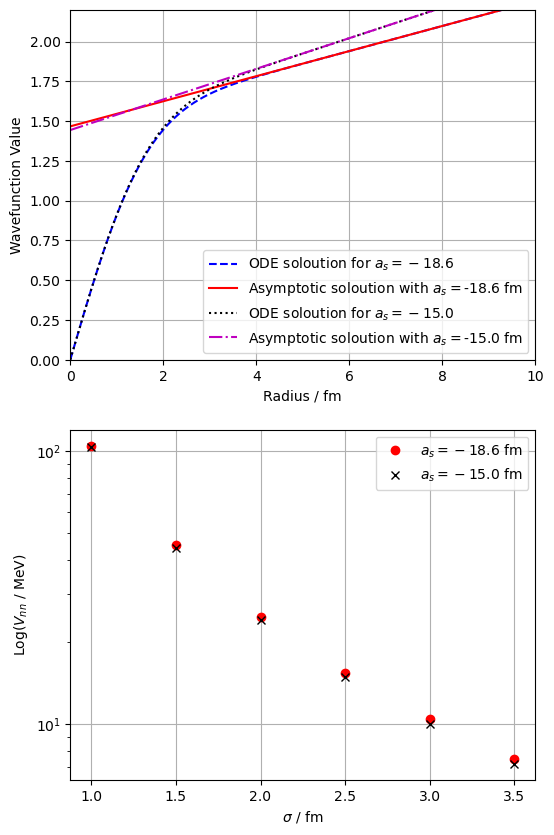

In [46]:
r_vals = np.linspace(0, R_MAX, 30001)
sol1 = second_order_ode_solver(scattering_strenths_a_18[2], r_vals, 2)
asymptotic_fit_parameters_18, asymptotic_fit_covarience_18 = asymptotic_fit(r_vals[1000:], sol1.y[1][1000:])

sol2 = second_order_ode_solver(scattering_strenths_a_15[2], r_vals, 2)
asymptotic_fit_parameters_15, asymptotic_fit_covarience_15 = asymptotic_fit(r_vals[1000:], sol2.y[1][1000:])


fig = plt.figure(figsize=(6, 10))
spec = fig.add_gridspec(ncols=1, nrows=2)
ax_1 = fig.add_subplot(spec[0, 0])
ax_1.plot(r_vals, sol1.y[1], c='b', linestyle='dashed', label=r'ODE soloution for $a_{s}=-18.6$')
ax_1.plot(r_vals, asymptotic_fit_parameters_18[0] * (1 - (r_vals) / asymptotic_fit_parameters_18[1]), c='r', label=r'Asymptotic soloution with $a_{s}=$'
    f'{asymptotic_fit_parameters_18[1]:.1f} fm')

ax_1.plot(r_vals, sol2.y[1], c='k', linestyle='dotted', label='ODE soloution for $a_{s}=-15.0$')
ax_1.plot(r_vals, asymptotic_fit_parameters_15[0] * (1 - (r_vals) / asymptotic_fit_parameters_15[1]), c='m', linestyle='-.', label=r'Asymptotic soloution with $a_{s}=$'
    f'{asymptotic_fit_parameters_15[1]:.1f} fm')
#ax_1.plot(r_vals, asymptotic_fit_parameters[0] * (1 - (r_vals) / -15), c='r', label=r'Asymptotic fit with $a_{s}=-15$ fm')

ax_1.set_xlim(left=0, right=10)
ax_1.set_ylim(bottom=0, top=2.2)
ax_1.legend()
#ax_1.set_title(r'$\sigma$ = 2 asymptotic fit')
ax_1.set_xlabel('Radius / fm')
ax_1.set_ylabel('Wavefunction Value')
ax_1.grid()

ax_2 = fig.add_subplot(spec[1, 0])
ax_2.semilogy(SCATTERING_RANGES, np.abs(scattering_strenths_a_18), 'or', label=r'$a_s=-18.6$ fm')
ax_2.semilogy(SCATTERING_RANGES, np.abs(scattering_strenths_a_15), 'xk', label=r'$a_s=-15.0$ fm')
ax_2.set_xlabel(r'$\sigma$ / fm')
ax_2.set_ylabel(r'Log($V_{nn}$ / MeV)')
ax_2.legend()
ax_2.grid()
plt.savefig('Scattering_Length_plot.png')


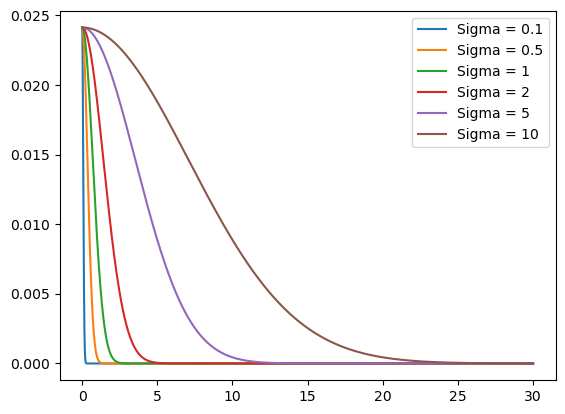

In [6]:
fig = plt.figure()
ax = fig.add_subplot()
range_params = [0.1, 0.5, 1, 2, 5, 10]
r_vals = np.linspace(0, 30, 10000)
for i in range_params:
    ax.plot(r_vals, neutron_neutron_potential(r_vals, 1, i), label=(f'Sigma = {i}'))
ax.legend()
